# Post-processing for MSM

Auhors: Kazuma Iwase and Tomoyuki Takenawa

at Tokyo University of Marine Science and Technology

## Note on released code and data

This notebook is provided to publicly release the code used in our research.
However, due to data licensing restrictions, some of the distributed datasets are **not the original (real) data** and are provided as **synthetic/derived substitutes**.
Therefore, running this notebook with the shared data may **not exactly reproduce the paper results**.



### Synthetic dataset for reproducibility (Google Drive)
Data link: https://drive.google.com/drive/folders/1-fViiakeGihCxSL0KHO2n0rxnDCnVpjd?usp=sharing


This folder contains **synthetic MSM/MSMG-like** inputs regenerated by a stcastic method (not the original MSM/MSMG data), while the observation CSVs are real JMA station observations.

To fully reproduce the results, you must obtain the original data separately (under the appropriate permissions) and prepare it in the **same file/column format** expected by this notebook.
In the notebook, switch `DATA_MODE="real"` (or adjust `MSM_DIR/MSMG_DIR`) to point to your real-data folders.


# Public weighted Tweedie notebook (Sekigahara, precipitation only)

This Colab notebook uses synthetic data for the public release.
It keeps the Optuna search for Tweedie power and sample weights, while using fixed pretrained LightGBM tree hyperparameters for the base precipitation model.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!pip install optuna-integration
!pip install --upgrade scikit-learn


In [2]:
from pathlib import Path

# ===== User settings =====
DATA_MODE = "synth"   # Use synthetic data in the public version
PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/Iwase/ml_postprocess")

# ===== Automatic settings =====
DATA_PUBLIC = PROJECT_ROOT / "data_public"
RESULTS_DIR = PROJECT_ROOT / "results_public"
OUTPUT_DIR  = PROJECT_ROOT / "output_public"

if DATA_MODE == "synth":
    MSM_DIR  = DATA_PUBLIC / "input_csv_synth"
    MSMG_DIR = DATA_PUBLIC / "msmg_csv_synth"
elif DATA_MODE == "real":
    MSM_DIR  = DATA_PUBLIC / "input_csv"
    MSMG_DIR = DATA_PUBLIC / "msmg_csv"
else:
    raise ValueError("DATA_MODE must be 'synth' or 'real'")

OBS_DIR = DATA_PUBLIC / "JMAobserve"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_MODE   =", DATA_MODE)
print("MSM_DIR     =", MSM_DIR)
print("OBS_DIR     =", OBS_DIR)
print("RESULTS_DIR =", RESULTS_DIR)
print("OUTPUT_DIR  =", OUTPUT_DIR)

DATA_MODE   = synth
MSM_DIR     = /content/drive/MyDrive/Colab Notebooks/Iwase/ml_postprocess/data_public/input_csv_synth
OBS_DIR     = /content/drive/MyDrive/Colab Notebooks/Iwase/ml_postprocess/data_public/JMAobserve
RESULTS_DIR = /content/drive/MyDrive/Colab Notebooks/Iwase/ml_postprocess/results_public
OUTPUT_DIR  = /content/drive/MyDrive/Colab Notebooks/Iwase/ml_postprocess/output_public


In [3]:
import datetime
import copy
import json
import numpy as np
import pandas as pd
import cupy as cp
import tensorflow as tf
import lightgbm as lgb
import optuna
import dask.bag as db

SEED = 1
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

In [4]:
# Sekigahara only
position_df = pd.DataFrame(
    columns=['Station_name', 'prec', 'block', 'lat', 'lon', 'alt', 'Station Number'],
    data=[['Sekigahara', 52, 495, 35.363, 136.467, 130, 52571]],
    index=['Sekigahara']
)
position_df

,Station_name,prec,block,lat,lon,alt,Station Number
Sekigahara,Sekigahara,52,495,35.363,136.467,130,52571


In [5]:
# Public weighted Tweedie notebook is precipitation-only
TARGET_COLUMNS = ['Precipitation', 'Temperature', 'Wind Speed']
PRECIP_COL = 'Precipitation'
PRECIP_COLUMNS = [PRECIP_COL]
outcolumns = TARGET_COLUMNS
outc = TARGET_COLUMNS

timelist = list(range(3, 40, 3))

BASE_SAVE_PREFIX = 'precip_base_lgbm_Sekigahara'
WEIGHTED_SAVE_PREFIX = 'precip_weighted_tweedie_Sekigahara'

### Functions for preprocessing

In [6]:
def split_data(h, hdf, outputdf):
    train_start = datetime.datetime(year=2019, month=1, day=1, hour=0) + datetime.timedelta(hours=h)
    train_end = datetime.datetime(year=2022, month=1, day=1, hour=0)
    validation_start = datetime.datetime(year=2022, month=1, day=1, hour=0) + datetime.timedelta(hours=h)
    validation_end = datetime.datetime(year=2023, month=1, day=1, hour=0)
    test_start = datetime.datetime(year=2023, month=1, day=1, hour=0) + datetime.timedelta(hours=h)
    test_end = datetime.datetime(year=2023, month=12, day=31, hour=21) + datetime.timedelta(hours=h)

    train_df = hdf.loc[train_start:train_end]
    validation_df = hdf.loc[validation_start:validation_end]
    test_df = hdf.loc[test_start:test_end]

    train_df = pd.concat([train_df, outputdf.loc[train_df.index]], axis=1)
    validation_df = pd.concat([validation_df, outputdf.loc[validation_df.index]], axis=1)
    test_df = pd.concat([test_df, outputdf.loc[test_df.index]], axis=1)
    return train_df, validation_df, test_df


def read_and_process_csv(pos, h, outputdf):
    fname = f"all_msm_synth_{pos}_{h}h.csv" if DATA_MODE == "synth" else f"all_msm_{pos}_{h}h.csv"
    hdf = pd.read_csv(MSM_DIR / pos / fname, index_col=0)
    hdf.index = pd.to_datetime(hdf.index)
    hdf.insert(0, 'predict_hour', np.full(len(hdf), h))
    hdf.insert(1, 'hour', hdf.index.hour)
    hdf.insert(2, 'month', hdf.index.month)
    return split_data(h, hdf, outputdf)


def get_train_validation_test_by_db(pos, timelist):
    outputdf = pd.read_csv(OBS_DIR / pos / f"all_jma_{pos}.csv", index_col=0)
    outputdf.index = pd.to_datetime(outputdf.index)

    bag = db.from_sequence(timelist)
    results = bag.map(lambda h: read_and_process_csv(pos, h, outputdf)).compute()
    train_combined_df_tuple, validation_combined_df_tuple, test_combined_df_tuple = zip(*results)
    train_combined_df = pd.concat(train_combined_df_tuple, axis=0)
    validation_combined_df = pd.concat(validation_combined_df_tuple, axis=0)
    test_hlist = list(test_combined_df_tuple)
    return train_combined_df, validation_combined_df, test_hlist


def feature_selection_cupy(df, threshold=0.9):
    columns = df.filter(regex=r'(0_0_t-0|0_0_t-1|0_0_t-2|0_0_p)').columns.tolist()
    columns += ['predict_hour', 'hour', 'month']
    df = df.drop(columns=columns)
    correlation_matrix = cp.corrcoef(cp.asarray(df.values), rowvar=False)
    correlation_matrix = cp.absolute(correlation_matrix)
    upper_cpu = cp.asnumpy(cp.where(cp.triu(cp.ones(correlation_matrix.shape), k=1).astype(bool), correlation_matrix, 0))
    drop_features = [column for column in df.columns if any(upper_cpu[:, df.columns.get_loc(column)] > threshold)]
    return drop_features


def feature_filter(w, s, p, df):
    ws_pattern = '|'.join([f'{i}_{j}_t-{l}' for i in range(-s, s + 1) for j in range(-s, s + 1) for l in range(w + 1)])
    p_pattern = '|'.join([f'{i}_{j}_p' for i in range(-p, p + 1) for j in range(-p, p + 1)])
    combined_pattern = f'{ws_pattern}|{p_pattern}|predict_hour|hour|month'
    return df.filter(regex=combined_pattern)


def get_xy_train_validation_test_precip(train_combined_df, validation_combined_df, test_list, grids='around'):
    if grids == '1grid':
        w, s, p = 2, 0, 0
    elif grids == 'around':
        w, s, p = 2, 5, 3
    else:
        raise ValueError("grids must be '1grid' or 'around'")

    train_combined_df = train_combined_df.dropna(subset=[PRECIP_COL])
    validation_mask = ~validation_combined_df[[PRECIP_COL]].isna().any(axis=1)

    x_train = train_combined_df.drop(columns=TARGET_COLUMNS)
    y_train = train_combined_df[[PRECIP_COL]]
    x_validation_all = validation_combined_df.drop(columns=TARGET_COLUMNS)
    y_validation_all = validation_combined_df[[PRECIP_COL]]

    x_train = feature_filter(w, s, p, x_train)
    feature_nums = x_train.shape[1]

    if grids == 'around':
        drop_features = feature_selection_cupy(x_train, threshold=0.9)
        x_train = x_train.drop(columns=drop_features)
    else:
        drop_features = []

    drop_feature_nums = x_train.shape[1]
    x_validation_all = x_validation_all[x_train.columns]

    x_test_all_list = []
    y_test_all_list = []
    test_mask_list = []
    for test_df in test_list:
        test_mask = ~test_df[[PRECIP_COL]].isna().any(axis=1)
        x_test_all = test_df.drop(columns=TARGET_COLUMNS)
        y_test_all = test_df[[PRECIP_COL]]
        x_test_all = x_test_all[x_train.columns]
        x_test_all_list.append(x_test_all)
        y_test_all_list.append(y_test_all)
        test_mask_list.append(test_mask)

    return {
        'x_train': x_train,
        'y_train': y_train,
        'x_validation_all': x_validation_all,
        'y_validation_all': y_validation_all,
        'validation_mask': validation_mask,
        'x_test_all_list': x_test_all_list,
        'y_test_all_list': y_test_all_list,
        'test_mask_list': test_mask_list,
        'feature_nums': feature_nums,
        'drop_feature_nums': drop_feature_nums,
        'drop_features': drop_features,
    }


def get_xy_data_for_one_position(pos='Sekigahara', timelist=timelist, grids='around'):
    train_combined_df, validation_combined_df, test_hlist = get_train_validation_test_by_db(pos, timelist)
    xy_data = get_xy_train_validation_test_precip(train_combined_df, validation_combined_df, test_hlist, grids=grids)
    xy_data['test_hlist'] = test_hlist
    return xy_data


def build_full_length_vector(pred_masked, mask, length=None):
    mask = np.asarray(mask, dtype=bool)
    pred_masked = np.asarray(pred_masked, dtype=np.float64).reshape(-1)
    if length is None:
        length = len(mask)
    if pred_masked.size != mask.sum():
        raise ValueError(f"pred_masked.size={pred_masked.size}, mask.sum()={mask.sum()}  do not match.")
    full = np.full(length, np.nan, dtype=np.float64)
    full[mask] = pred_masked
    return full

In [7]:
# Pretrained tree hyperparameters for precipitation
# Keep these fixed; no early-stage hyperparameter tuning is performed here
best_params_precip_base = {
    'boosting_type': 'gbdt',
    'objective': 'regression',
    'metric': 'rmse',
    'verbose': -1,
    'num_threads': -1,
    'seed': 1,
    'feature_pre_filter': False,
    'lambda_l1': 7.209686166378859,
    'lambda_l2': 2.066175777750847e-08,
    'num_leaves': 42,
    'feature_fraction': 0.4,
    'bagging_fraction': 0.9716669565170222,
    'bagging_freq': 1,
    'min_child_samples': 100,
}

pd.Series(best_params_precip_base)

,0
boosting_type,gbdt
objective,regression
metric,rmse
verbose,-1
num_threads,-1
seed,1
feature_pre_filter,False
lambda_l1,7.209686
lambda_l2,0.0
num_leaves,42


### Functions for eventmetrics and Tweedie

In [8]:
def train_lgbm_precip_regression(
    x_train,
    y_train,
    x_validation,
    y_validation,
    params,
    num_boost_round=10000,
    patience=10,
    verbose=False,
):
    y_train = np.asarray(y_train, dtype=np.float64).reshape(-1)
    y_validation = np.asarray(y_validation, dtype=np.float64).reshape(-1)
    lgb_train = lgb.Dataset(x_train, y_train)
    lgb_eval = lgb.Dataset(x_validation, y_validation, reference=lgb_train)
    gbm = lgb.train(
        params,
        lgb_train,
        num_boost_round=num_boost_round,
        valid_sets=[lgb_eval],
        callbacks=[lgb.early_stopping(stopping_rounds=patience, verbose=verbose)],
    )
    return gbm


def predict_lgbm_precip_regression(model, x):
    best_iteration = model.best_iteration if model.best_iteration is not None else model.current_iteration()
    pred = model.predict(x, num_iteration=best_iteration)
    return np.maximum(np.asarray(pred, dtype=np.float64), 0.0)


def make_precip_sample_weights(
    y,
    moderate_th=5.0,
    heavy_th=10.0,
    moderate_w=1.0,
    heavy_w=1.0,
):
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    w = np.ones_like(y, dtype=np.float64)
    w[y >= moderate_th] = moderate_w
    w[y >= heavy_th] = heavy_w
    return w


def make_tweedie_params(base_params, tweedie_variance_power):
    params = copy.deepcopy(base_params)
    params['objective'] = 'tweedie'
    params['metric'] = 'tweedie'
    params['tweedie_variance_power'] = float(tweedie_variance_power)
    params['verbose'] = -1
    params['num_threads'] = -1
    params['seed'] = SEED
    return params


def train_lgbm_precip_tweedie(
    x_train,
    y_train,
    x_validation,
    y_validation,
    sample_weight=None,
    params=None,
    num_boost_round=10000,
    patience=10,
    verbose=False,
):
    y_train = np.asarray(y_train, dtype=np.float64).reshape(-1)
    y_validation = np.asarray(y_validation, dtype=np.float64).reshape(-1)
    lgb_train = lgb.Dataset(x_train, y_train, weight=sample_weight)
    lgb_eval = lgb.Dataset(x_validation, y_validation, reference=lgb_train)
    gbm = lgb.train(
        params,
        lgb_train,
        num_boost_round=num_boost_round,
        valid_sets=[lgb_eval],
        callbacks=[lgb.early_stopping(stopping_rounds=patience, verbose=verbose)],
    )
    return gbm


def predict_lgbm_precip_tweedie(model, x):
    best_iteration = model.best_iteration if model.best_iteration is not None else model.current_iteration()
    pred = model.predict(x, num_iteration=best_iteration)
    return np.maximum(np.asarray(pred, dtype=np.float64), 0.0)


def compute_event_metrics_1d(y_pred, y_true, threshold=10.0):
    yp = np.asarray(y_pred, dtype=np.float64).reshape(-1)
    yt = np.asarray(y_true, dtype=np.float64).reshape(-1)
    mask = (~np.isnan(yp)) & (~np.isnan(yt))
    yp = yp[mask]
    yt = yt[mask]

    pred_event = yp >= threshold
    true_event = yt >= threshold

    hit = int(np.sum(pred_event & true_event))
    miss = int(np.sum((~pred_event) & true_event))
    false_alarm = int(np.sum(pred_event & (~true_event)))

    ts_den = hit + miss + false_alarm
    pod_den = hit + miss
    far_den = hit + false_alarm

    ts = hit / ts_den if ts_den > 0 else np.nan
    pod = hit / pod_den if pod_den > 0 else np.nan
    far = false_alarm / far_den if far_den > 0 else np.nan
    bias = (hit + false_alarm) / pod_den if pod_den > 0 else np.nan

    return {
        'hit': hit,
        'miss': miss,
        'false_alarm': false_alarm,
        'TS': ts,
        'POD': pod,
        'FAR': far,
        'Bias': bias,
    }


def compute_me_1d(y_pred, y_true):
    yp = np.asarray(y_pred, dtype=np.float64).reshape(-1)
    yt = np.asarray(y_true, dtype=np.float64).reshape(-1)
    mask = (~np.isnan(yp)) & (~np.isnan(yt))
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(yp[mask] - yt[mask]))


def compute_rmse_1d(y_pred, y_true):
    yp = np.asarray(y_pred, dtype=np.float64).reshape(-1)
    yt = np.asarray(y_true, dtype=np.float64).reshape(-1)
    mask = np.isfinite(yp) & np.isfinite(yt)
    if mask.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((yp[mask] - yt[mask]) ** 2)))


def compute_weighted_ts_score(
    y_pred,
    y_true,
    thresholds=(1.0, 5.0, 10.0),
    weights=(0.25, 0.25, 0.50),
    alpha=0.0,
    beta=0.0,
):
    if len(thresholds) != len(weights):
        raise ValueError('The lengths of thresholds and weights do not match.')

    yp = np.asarray(y_pred, dtype=np.float64).reshape(-1)
    yt = np.asarray(y_true, dtype=np.float64).reshape(-1)
    mask = (~np.isnan(yp)) & (~np.isnan(yt))
    yp = yp[mask]
    yt = yt[mask]

    details = {}
    score_ts = 0.0
    for thr, w in zip(thresholds, weights):
        m = compute_event_metrics_1d(yp, yt, threshold=thr)
        thr_label = int(thr) if float(thr).is_integer() else thr
        details[f'TS_{thr_label}mm'] = m['TS']
        details[f'POD_{thr_label}mm'] = m['POD']
        details[f'FAR_{thr_label}mm'] = m['FAR']
        details[f'Bias_{thr_label}mm'] = m['Bias']
        score_ts += float(w) * (0.0 if np.isnan(m['TS']) else m['TS'])

    me = compute_me_1d(yp, yt)
    true_mean = float(np.mean(yt)) if len(yt) > 0 else np.nan

    penalty_bias = 0.0
    if alpha > 0.0:
        bias10 = details.get('Bias_10mm', np.nan)
        if np.isfinite(bias10):
            penalty_bias = alpha * abs(np.log(np.clip(bias10, 1e-8, None)))

    penalty_me = 0.0
    if beta > 0.0 and np.isfinite(me) and np.isfinite(true_mean) and abs(true_mean) > 1e-12:
        penalty_me = beta * abs(me / true_mean)

    score_total = score_ts - penalty_bias - penalty_me
    details['ME'] = me
    details['true_mean_precip'] = true_mean
    details['Score_TS_weighted'] = score_ts
    details['penalty_bias'] = penalty_bias
    details['penalty_me'] = penalty_me
    details['Score_total'] = score_total
    return score_total, details

### Train the base precipitation LGBM with fixed parameters


In [9]:
# Train the base precipitation LGBM with fixed parameters
xy_data = get_xy_data_for_one_position(pos='Sekigahara', timelist=timelist, grids='around')

x_train = xy_data['x_train']
y_train = xy_data['y_train'][PRECIP_COL].clip(lower=0.0)
validation_mask = xy_data['validation_mask']
x_validation_all = xy_data['x_validation_all']
y_validation_all = xy_data['y_validation_all'][PRECIP_COL].clip(lower=0.0)

x_validation = x_validation_all.loc[validation_mask]
y_validation = y_validation_all.loc[validation_mask]

base_model = train_lgbm_precip_regression(
    x_train=x_train,
    y_train=y_train,
    x_validation=x_validation,
    y_validation=y_validation,
    params=best_params_precip_base,
    num_boost_round=10000,
    patience=10,
    verbose=False,
)

base_val_pred_masked = predict_lgbm_precip_regression(base_model, x_validation)
base_val_pred_full = build_full_length_vector(base_val_pred_masked, validation_mask, length=len(y_validation_all))

base_test_pred_list = []
for j, h in enumerate(timelist):
    x_test_all = xy_data['x_test_all_list'][j]
    test_mask = xy_data['test_mask_list'][j]
    base_test_pred_masked = predict_lgbm_precip_regression(base_model, x_test_all.loc[test_mask])
    base_test_pred_full = build_full_length_vector(base_test_pred_masked, test_mask, length=len(x_test_all))
    base_test_pred_list.append(base_test_pred_full)

# np.savez_compressed(OUTPUT_DIR / f'{BASE_SAVE_PREFIX}_val_pred.npz', np.array([base_val_pred_full], dtype=object))
# np.savez_compressed(OUTPUT_DIR / f'{BASE_SAVE_PREFIX}_test_pred.npz', np.array([base_test_pred_list], dtype=object))

# print('saved:')
# print(OUTPUT_DIR / f'{BASE_SAVE_PREFIX}_val_pred.npz')
# print(OUTPUT_DIR / f'{BASE_SAVE_PREFIX}_test_pred.npz')

### Optimization of the  Tweedie and sample-weight hyperparameters with Optuna

In [10]:
# Optimize only the Tweedie and sample-weight hyperparameters with Optuna
# Tree hyperparameters are fixed to best_params_precip_base

def objective_precip_tweedie_weighted(
    trial,
    xy_data,
    base_precip_params,
    thresholds=(1.0, 5.0, 10.0),
    weights=(0.25, 0.25, 0.50),
    alpha=0.0,
    beta=0.0,
    moderate_th=5.0,
    heavy_th=10.0,
    num_boost_round=10000,
    patience=10,
    verbose=False,
):
    tweedie_variance_power = trial.suggest_float('tweedie_variance_power', 1.20, 1.60, step=0.05)
    moderate_w = trial.suggest_float('moderate_w', 1.00, 4.00, step=0.25)
    heavy_w = trial.suggest_float('heavy_w', moderate_w, 8.00, step=0.25)

    params = make_tweedie_params(base_precip_params, tweedie_variance_power)

    x_train = xy_data['x_train']
    y_train = xy_data['y_train'][PRECIP_COL].clip(lower=0.0)
    validation_mask = xy_data['validation_mask']
    x_validation_all = xy_data['x_validation_all']
    y_validation_all = xy_data['y_validation_all'][PRECIP_COL].clip(lower=0.0)
    x_validation = x_validation_all.loc[validation_mask]
    y_validation = y_validation_all.loc[validation_mask]

    sample_weight = make_precip_sample_weights(
        y_train,
        moderate_th=moderate_th,
        heavy_th=heavy_th,
        moderate_w=moderate_w,
        heavy_w=heavy_w,
    )

    model = train_lgbm_precip_tweedie(
        x_train=x_train,
        y_train=y_train,
        x_validation=x_validation,
        y_validation=y_validation,
        sample_weight=sample_weight,
        num_boost_round=num_boost_round,
        patience=patience,
        verbose=verbose,
        params=params,
    )

    val_pred = predict_lgbm_precip_tweedie(model, x_validation)
    score, details = compute_weighted_ts_score(
        val_pred,
        y_validation,
        thresholds=thresholds,
        weights=weights,
        alpha=alpha,
        beta=beta,
    )

    for k, v in details.items():
        trial.set_user_attr(k, v)
    trial.set_user_attr('tweedie_variance_power', tweedie_variance_power)
    trial.set_user_attr('moderate_w', moderate_w)
    trial.set_user_attr('heavy_w', heavy_w)
    return score


def optuna_progress_callback(study, trial):
    attrs = trial.user_attrs
    print(
        f"[trial {trial.number:03d}] "
        f"score={trial.value:.5f} | "
        f"TS1={attrs.get('TS_1mm', np.nan):.4f}, "
        f"TS5={attrs.get('TS_5mm', np.nan):.4f}, "
        f"TS10={attrs.get('TS_10mm', np.nan):.4f}, "
        f"ME={attrs.get('ME', np.nan):.4f}"
    )

sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction='maximize', sampler=sampler, study_name='public_weighted_tweedie_sekigahara_precip_only')

study.optimize(
    lambda trial: objective_precip_tweedie_weighted(
        trial=trial,
        xy_data=xy_data,
        base_precip_params=best_params_precip_base,
        thresholds=(1.0, 5.0, 10.0),
        weights=(0.25, 0.25, 0.50),
        alpha=0.0,
        beta=0.0,
        moderate_th=5.0,
        heavy_th=10.0,
        num_boost_round=10000,
        patience=10,
        verbose=False,
    ),
    n_trials=50,
    show_progress_bar=True,
    callbacks=[optuna_progress_callback],
)

display(pd.Series(study.best_params))
print('best score =', study.best_value)

with open(OUTPUT_DIR / 'weighted_tweedie_best_params_sekigahara_precip_only.json', 'w') as f:
    json.dump(study.best_params, f, indent=2)

[I 2026-03-26 09:32:31,242] A new study created in memory with name: public_weighted_tweedie_sekigahara_precip_only


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-26 09:32:37,002] Trial 0 finished with value: 0.27810625976228964 and parameters: {'tweedie_variance_power': 1.35, 'moderate_w': 3.25, 'heavy_w': 3.25}. Best is trial 0 with value: 0.27810625976228964.
[trial 000] score=0.27811 | TS1=0.5155, TS5=0.3037, TS10=0.1466, ME=0.1203
[I 2026-03-26 09:32:39,449] Trial 1 finished with value: 0.27081746189301775 and parameters: {'tweedie_variance_power': 1.3, 'moderate_w': 1.25, 'heavy_w': 1.75}. Best is trial 0 with value: 0.27810625976228964.
[trial 001] score=0.27082 | TS1=0.5218, TS5=0.2999, TS10=0.1308, ME=0.0302
[I 2026-03-26 09:32:42,593] Trial 2 finished with value: 0.2834020082700923 and parameters: {'tweedie_variance_power': 1.25, 'moderate_w': 2.0, 'heavy_w': 4.25}. Best is trial 2 with value: 0.2834020082700923.
[trial 002] score=0.28340 | TS1=0.5183, TS5=0.3095, TS10=0.1529, ME=0.1154
[I 2026-03-26 09:32:45,466] Trial 3 finished with value: 0.2916180706228668 and parameters: {'tweedie_variance_power': 1.4, 'moderate_w': 2.

,0
tweedie_variance_power,1.55
moderate_w,2.00
heavy_w,6.50


best score = 0.3053404435858201


### Prediction by the weighted Tweedie model

In [11]:
# Retrain precipitation with the best trial and save validation/test predictions
best_cfg = study.best_params.copy()
best_params_precip_tweedie = make_tweedie_params(best_params_precip_base, best_cfg['tweedie_variance_power'])

sample_weight = make_precip_sample_weights(
    y_train,
    moderate_th=5.0,
    heavy_th=10.0,
    moderate_w=best_cfg['moderate_w'],
    heavy_w=best_cfg['heavy_w'],
)

best_weighted_model = train_lgbm_precip_tweedie(
    x_train=x_train,
    y_train=y_train,
    x_validation=x_validation,
    y_validation=y_validation,
    sample_weight=sample_weight,
    num_boost_round=10000,
    patience=10,
    verbose=True,
    params=best_params_precip_tweedie,
)

weighted_val_pred_masked = predict_lgbm_precip_tweedie(best_weighted_model, x_validation)
weighted_val_pred_full = build_full_length_vector(weighted_val_pred_masked, validation_mask, length=len(y_validation_all))
weighted_val_pair = np.column_stack([base_val_pred_full, weighted_val_pred_full])

weighted_test_pair_list = []
for j, h in enumerate(timelist):
    x_test_all = xy_data['x_test_all_list'][j]
    test_mask = xy_data['test_mask_list'][j]
    weighted_test_pred_masked = predict_lgbm_precip_tweedie(best_weighted_model, x_test_all.loc[test_mask])
    weighted_test_pred_full = build_full_length_vector(weighted_test_pred_masked, test_mask, length=len(x_test_all))
    weighted_test_pair = np.column_stack([base_test_pred_list[j], weighted_test_pred_full])
    weighted_test_pair_list.append(weighted_test_pair)

# np.savez_compressed(OUTPUT_DIR / f'{WEIGHTED_SAVE_PREFIX}_val_pred.npz', np.array([weighted_val_pair], dtype=object))
# np.savez_compressed(OUTPUT_DIR / f'{WEIGHTED_SAVE_PREFIX}_test_pred.npz', np.array([weighted_test_pair_list], dtype=object))

# print('saved:')
# print(OUTPUT_DIR / f'{WEIGHTED_SAVE_PREFIX}_val_pred.npz')
# print(OUTPUT_DIR / f'{WEIGHTED_SAVE_PREFIX}_test_pred.npz')

Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[49]	valid_0's tweedie: 1.92798


Comparison tables

In [12]:
##############################
# Observation + MSMG helpers
# No MSM input reading
##############################

import numpy as np
import pandas as pd

SITE_NAME = "Sekigahara"
EVAL_THRESHOLDS = (1.0, 5.0, 10.0, 15.0)

def read_msmg(pos, h):
    hfname = f"all_msmg_synth_{pos}_{h}h.csv" if DATA_MODE == "synth" else f"all_msmg_{pos}_{h}h.csv"
    hdf = pd.read_csv(MSMG_DIR / pos / hfname, index_col=0)
    hdf.index = pd.to_datetime(hdf.index)
    return hdf

def get_obs_precip_for_lead(j):
    y_true_obj = xy_data["y_test_all_list"][j][PRECIP_COL]
    y_true = np.asarray(y_true_obj.to_numpy(), dtype=np.float64)
    obs_index = pd.to_datetime(y_true_obj.index)
    return y_true, obs_index


##############################
# Paper-style precipitation tables
# overall + by lead
# Models: MSMG / around all tune / weighted Tweedie
##############################

import numpy as np
import pandas as pd

EVAL_THRESHOLDS = (1.0, 5.0, 10.0, 15.0)

def get_precip_base(arr_pred):
    arr_pred = np.asarray(arr_pred, dtype=np.float64)
    return arr_pred[:, 0].copy()


def get_precip_weighted(arr_pred):
    arr_pred = np.asarray(arr_pred, dtype=np.float64)
    yp = arr_pred[:, 1].copy()
    base_yp = arr_pred[:, 0]
    nan_mask = ~np.isfinite(yp)
    yp[nan_mask] = base_yp[nan_mask]
    return yp


def _precip_window_label(h):
    return f"{h-3}–{h} h accumulated precipitation"

def get_obs_precip_for_lead(j):
    y_true_obj = xy_data["y_test_all_list"][j][PRECIP_COL]
    y_true = np.asarray(y_true_obj.to_numpy(), dtype=np.float64)
    obs_index = pd.to_datetime(y_true_obj.index)
    return y_true, obs_index

def get_msmg_precip_for_lead(j):
    h = timelist[j]
    _, obs_index = get_obs_precip_for_lead(j)

    msmg_df = read_msmg(SITE_NAME, h)

    if "tp" in msmg_df.columns:
        msmg_series = msmg_df["tp"]
    else:
        msmg_series = msmg_df.iloc[:, 0]

    msmg_series = msmg_series.reindex(obs_index)
    return np.asarray(msmg_series.to_numpy(), dtype=np.float64)

def build_paper_style_rows(y_true, y_msmg, y_base, y_weighted, site_name, case_label, lead_h):
    rows = []

    for thr in EVAL_THRESHOLDS:
        m_msmg = compute_event_metrics_1d(y_msmg, y_true, threshold=thr)
        m_base = compute_event_metrics_1d(y_base, y_true, threshold=thr)
        m_weighted = compute_event_metrics_1d(y_weighted, y_true, threshold=thr)

        rows.append({
            "Site": site_name,
            "lead_h": lead_h,
            "Case": case_label,
            "Model": "MSMG",
            "Threshold (mm)": thr,
            "TS": m_msmg["TS"],
            "POD": m_msmg["POD"],
            "Bias": m_msmg["Bias"],
        })
        rows.append({
            "Site": site_name,
            "lead_h": lead_h,
            "Case": case_label,
            "Model": "around all tune",
            "Threshold (mm)": thr,
            "TS": m_base["TS"],
            "POD": m_base["POD"],
            "Bias": m_base["Bias"],
        })
        rows.append({
            "Site": site_name,
            "lead_h": lead_h,
            "Case": case_label,
            "Model": "weighted Tweedie",
            "Threshold (mm)": thr,
            "TS": m_weighted["TS"],
            "POD": m_weighted["POD"],
            "Bias": m_weighted["Bias"],
        })

    return rows

# --------------------------
# by-lead table
# --------------------------
paper_by_lead_rows = []

all_true = []
all_msmg = []
all_base = []
all_weighted = []

for j, h in enumerate(timelist):
    y_true, _ = get_obs_precip_for_lead(j)
    y_msmg = get_msmg_precip_for_lead(j)
    y_base = get_precip_base(weighted_test_pair_list[j])
    y_weighted = get_precip_weighted(weighted_test_pair_list[j])

    all_true.append(y_true)
    all_msmg.append(y_msmg)
    all_base.append(y_base)
    all_weighted.append(y_weighted)

    paper_by_lead_rows.extend(
        build_paper_style_rows(
            y_true=y_true,
            y_msmg=y_msmg,
            y_base=y_base,
            y_weighted=y_weighted,
            site_name=SITE_NAME,
            case_label=_precip_window_label(h),
            lead_h=h,
        )
    )

paper_by_lead_df = pd.DataFrame(paper_by_lead_rows)

# --------------------------
# overall table
# --------------------------
y_true_all = np.concatenate(all_true)
y_msmg_all = np.concatenate(all_msmg)
y_base_all = np.concatenate(all_base)
y_weighted_all = np.concatenate(all_weighted)

paper_overall_rows = build_paper_style_rows(
    y_true=y_true_all,
    y_msmg=y_msmg_all,
    y_base=y_base_all,
    y_weighted=y_weighted_all,
    site_name=SITE_NAME,
    case_label="all lead times",
    lead_h="overall",
)

paper_overall_df = pd.DataFrame(paper_overall_rows)

# sort for readability
model_order = {"MSMG": 0, "around all tune": 1, "weighted Tweedie": 2}
paper_by_lead_df["model_order"] = paper_by_lead_df["Model"].map(model_order)
paper_overall_df["model_order"] = paper_overall_df["Model"].map(model_order)

paper_by_lead_df = (
    paper_by_lead_df
    .sort_values(["lead_h", "Threshold (mm)", "model_order"])
    .drop(columns=["model_order"])
    .reset_index(drop=True)
)

paper_overall_df = (
    paper_overall_df
    .sort_values(["Threshold (mm)", "model_order"])
    .drop(columns=["model_order"])
    .reset_index(drop=True)
)

display(paper_overall_df.round(4))
display(paper_by_lead_df.round(4))

paper_overall_df.to_csv(
    RESULTS_DIR / "paper_style_overall_sekigahara_with_msmg.csv",
    index=False,
    encoding="utf-8-sig",
)
paper_by_lead_df.to_csv(
    RESULTS_DIR / "paper_style_by_lead_sekigahara_with_msmg.csv",
    index=False,
    encoding="utf-8-sig",
)

print("saved:")
print(RESULTS_DIR / "paper_style_overall_sekigahara_with_msmg.csv")
print(RESULTS_DIR / "paper_style_by_lead_sekigahara_with_msmg.csv")

,Site,lead_h,Case,Model,Threshold (mm),TS,POD,Bias
0,Sekigahara,overall,all lead times,MSMG,1.0,0.5029,0.7344,1.1949
1,Sekigahara,overall,all lead times,around all tune,1.0,0.4897,0.7710,1.3454
2,Sekigahara,overall,all lead times,weighted Tweedie,1.0,0.5022,0.7761,1.3215
3,Sekigahara,overall,all lead times,MSMG,5.0,0.4160,0.6212,1.1144
4,Sekigahara,overall,all lead times,around all tune,5.0,0.3857,0.5029,0.8067
5,Sekigahara,overall,all lead times,weighted Tweedie,5.0,0.3798,0.6891,1.5036
6,Sekigahara,overall,all lead times,MSMG,10.0,0.3143,0.5139,1.1489
7,Sekigahara,overall,all lead times,around all tune,10.0,0.2845,0.3306,0.4926
8,Sekigahara,overall,all lead times,weighted Tweedie,10.0,0.3030,0.5401,1.3224
9,Sekigahara,overall,all lead times,MSMG,15.0,0.2708,0.4215,0.9785


,Site,lead_h,Case,Model,Threshold (mm),TS,POD,Bias
0,Sekigahara,3,0–3 h accumulated precipitation,MSMG,1.0,0.5810,0.8295,1.2572
1,Sekigahara,3,0–3 h accumulated precipitation,around all tune,1.0,0.5380,0.8382,1.3960
2,Sekigahara,3,0–3 h accumulated precipitation,weighted Tweedie,1.0,0.5714,0.8439,1.3208
3,Sekigahara,3,0–3 h accumulated precipitation,MSMG,5.0,0.4800,0.7000,1.1583
4,Sekigahara,3,0–3 h accumulated precipitation,around all tune,5.0,0.4342,0.5500,0.8167
...,...,...,...,...,...,...,...,...
151,Sekigahara,39,36–39 h accumulated precipitation,around all tune,10.0,0.2075,0.2340,0.3617
152,Sekigahara,39,36–39 h accumulated precipitation,weighted Tweedie,10.0,0.2584,0.4894,1.3830
153,Sekigahara,39,36–39 h accumulated precipitation,MSMG,15.0,0.2973,0.4400,0.9200
154,Sekigahara,39,36–39 h accumulated precipitation,around all tune,15.0,0.0741,0.0800,0.1600


saved:
/content/drive/MyDrive/Colab Notebooks/Iwase/ml_postprocess/results_public/paper_style_overall_sekigahara_with_msmg.csv
/content/drive/MyDrive/Colab Notebooks/Iwase/ml_postprocess/results_public/paper_style_by_lead_sekigahara_with_msmg.csv


### Plot

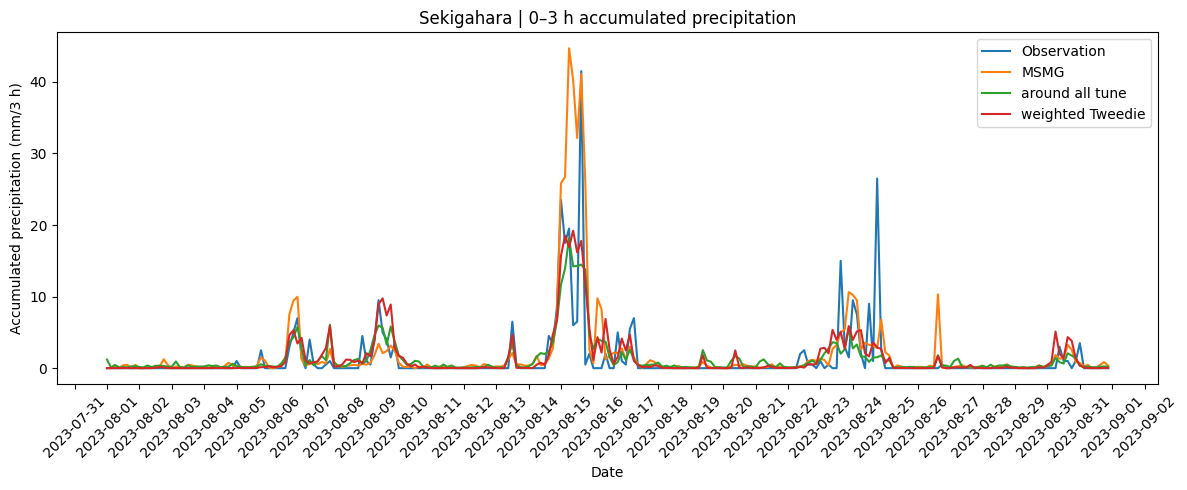

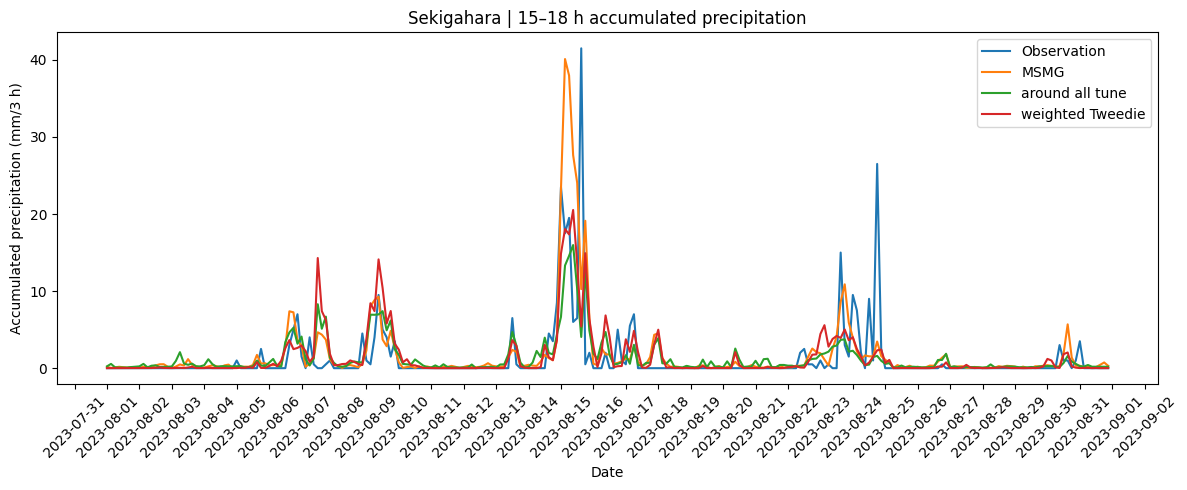

saved:
/content/drive/MyDrive/Colab Notebooks/Iwase/ml_postprocess/results_public/Sekigahara_0_3h_precip_compare_with_msmg.png
/content/drive/MyDrive/Colab Notebooks/Iwase/ml_postprocess/results_public/Sekigahara_15_18h_precip_compare_with_msmg.png


In [13]:
##############################
# Representative-case plots
# observation + MSMG + around all tune + weighted Tweedie
# No MSM input reading
##############################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def _precip_window_label(h):
    return f"{h-3}–{h} h accumulated precipitation"

def _panel_title(site_name, h):
    return f"{site_name} | {_precip_window_label(h)}"

def get_obs_precip_for_lead(j):
    y_true_obj = xy_data["y_test_all_list"][j][PRECIP_COL]
    y_true = np.asarray(y_true_obj.to_numpy(), dtype=np.float64)
    obs_index = pd.to_datetime(y_true_obj.index)
    return y_true, obs_index

def get_msmg_precip_for_lead(j):
    h = timelist[j]
    _, obs_index = get_obs_precip_for_lead(j)

    msmg_df = read_msmg(SITE_NAME, h)

    if "tp" in msmg_df.columns:
        msmg_series = msmg_df["tp"]
    else:
        msmg_series = msmg_df.iloc[:, 0]

    msmg_series = msmg_series.reindex(obs_index)
    return np.asarray(msmg_series.to_numpy(), dtype=np.float64)

def plot_precip_compare_with_msmg(site_name, h, month_start, month_end, save_path=None):
    j = list(timelist).index(h)

    y_true, obs_index = get_obs_precip_for_lead(j)
    y_msmg = get_msmg_precip_for_lead(j)
    y_base = get_precip_base(weighted_test_pair_list[j])
    y_weighted = get_precip_weighted(weighted_test_pair_list[j])

    df_plot = pd.DataFrame({
        "Observation": y_true,
        "MSMG": y_msmg,
        "around all tune": y_base,
        "weighted Tweedie": y_weighted,
    }, index=obs_index)

    mask = (df_plot.index.month >= month_start) & (df_plot.index.month <= month_end)
    df_plot = df_plot.loc[mask]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df_plot.index, df_plot["Observation"], label="Observation", linewidth=1.5)
    ax.plot(df_plot.index, df_plot["MSMG"], label="MSMG", linewidth=1.5)
    ax.plot(df_plot.index, df_plot["around all tune"], label="around all tune", linewidth=1.5)
    ax.plot(df_plot.index, df_plot["weighted Tweedie"], label="weighted Tweedie", linewidth=1.5)

    ax.legend()
    ax.set_title(_panel_title(site_name, h))
    ax.set_xlabel("Date")
    ax.set_ylabel("Accumulated precipitation (mm/3 h)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.tick_params(axis="x", rotation=45)

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()
    plt.close(fig)


# Example representative cases
plot_precip_compare_with_msmg(
    site_name=SITE_NAME,
    h=3,
    month_start=8,
    month_end=8,
    save_path=RESULTS_DIR / "Sekigahara_0_3h_precip_compare_with_msmg.png",
)

plot_precip_compare_with_msmg(
    site_name=SITE_NAME,
    h=18,
    month_start=8,
    month_end=8,
    save_path=RESULTS_DIR / "Sekigahara_15_18h_precip_compare_with_msmg.png",
)

print("saved:")
print(RESULTS_DIR / "Sekigahara_0_3h_precip_compare_with_msmg.png")
print(RESULTS_DIR / "Sekigahara_15_18h_precip_compare_with_msmg.png")